In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Examine distribution of response variable
print(df['Potability'].value_counts())

# Number of NAs
print(df.isna().sum())

Potability
0    1998
1    1278
Name: count, dtype: int64
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [9]:
# Fill those nas
df_clean = df.fillna(df.median())

# Split data
features = df.drop(columns=['Potability']).columns.tolist()
X = df_clean[features]
y = df_clean['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .3, stratify= y, random_state= 42)



In [10]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [15]:
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

print(f"Untuned tree depth:  {tree_depth}")
print(f"Training accuracy:         {dt_unpruned_acc_train:.3f}")
print(f"Test accuracy:             {dt_unpruned_acc_test:.3f}")

Untuned tree depth:  33
Training accuracy:         1.000
Test accuracy:             0.581


In [13]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

Training accuracy is 1, a perfect classifier, while test accuracy is only ~.6 which indicates overfitting as we are fitting our training data MUCH better than our test data. This means that at an untuned depth our model is sensitive to new data. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Best max_depth (5-fold CV): 7  (CV accuracy: 0.639)


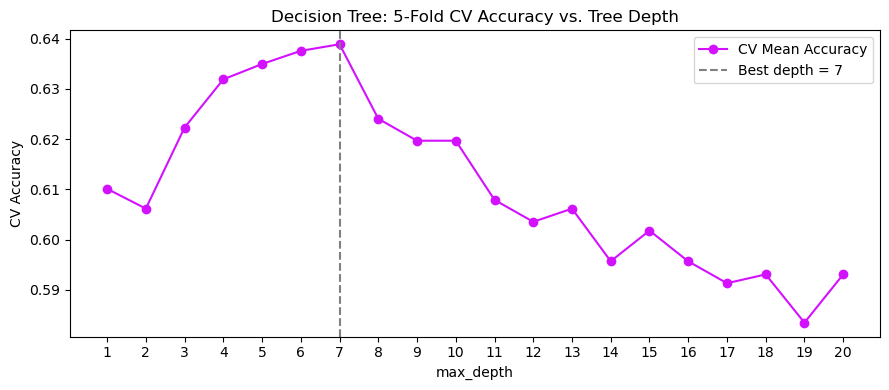

In [21]:
# Get depth range
depths = range(1,21)
cv_means = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth = depth, random_state= 42)
    scores = cross_val_score(dt, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)


optimal_depth   = list(depths)[np.argmax(cv_means)]

print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {cv_means.max():.3f})")


plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, color = '#D311FF',label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

The cross validation found the optimal depth to be 7. At this depth we are able to classify 63.9% of our predictions. By making the depth of the decision tree 7 we obtain the highest accuracy, without overfitting on the training data. 

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [32]:
# Re-fit the tree
dt_opt = DecisionTreeClassifier(max_depth = 7, random_state= 42)
dt_opt.fit(X_train, y_train)

# Get accuracy
dt_tuned_acc_train = accuracy_score(y_train, dt_opt.predict(X_train))
acc_dt = accuracy_score(y_test, dt_opt.predict(X_test)) 

print(f"Training accuracy:         {dt_tuned_acc_train:.3f}")
print(f"Test accuracy:             {acc_dt:.3f}")

Training accuracy:         0.730
Test accuracy:             0.646


In [29]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Our test accuracy increased by .06 and the training accuracy lowered by .17. The test accuracy improved due to less overfitting (caused by less tree depth being used), meaning that the model is more generalizable. This is also why the training accuracy falls, as the data wasn't 'perfectly trained'.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

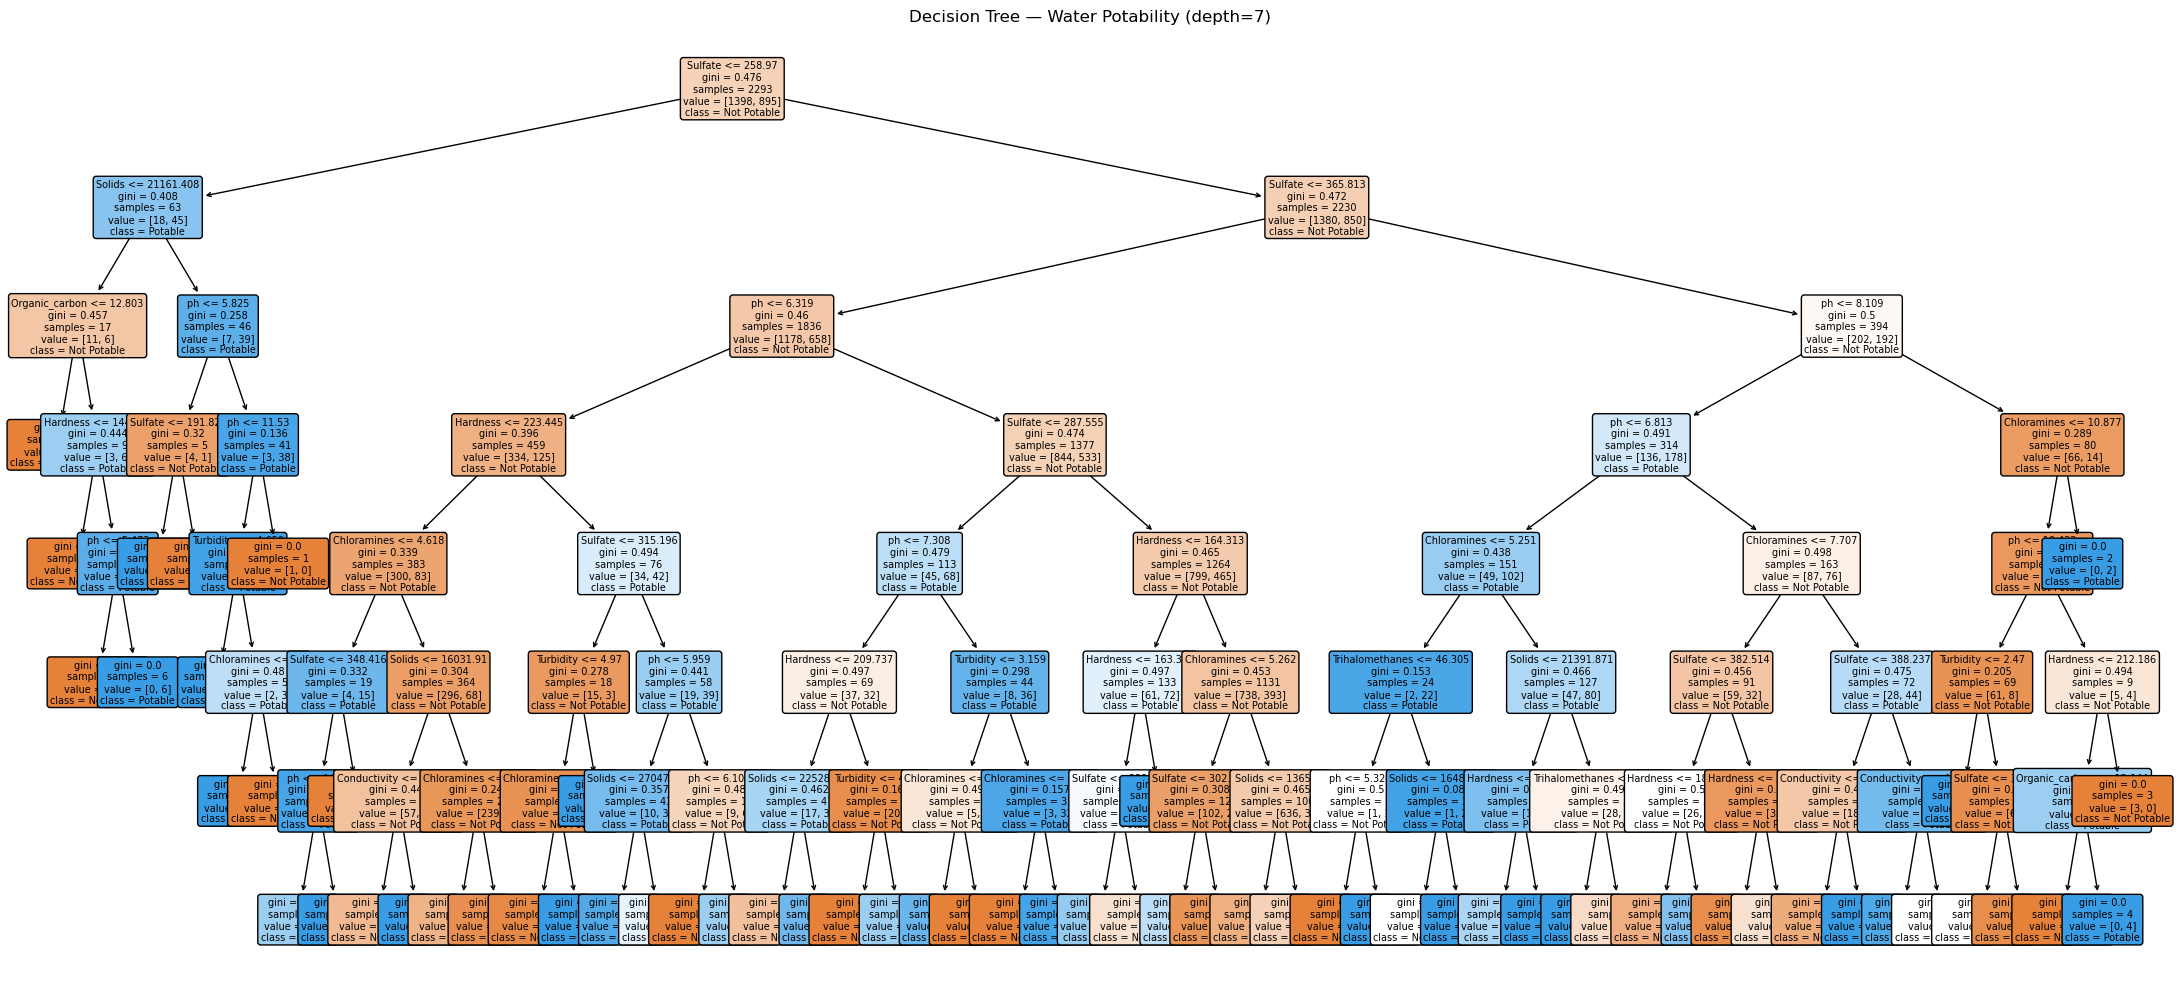

In [35]:
plt.figure(figsize=(22, 10))
class_names = ["Not Potable", "Potable"]
               
# Plot tree
plot_tree(dt_opt, feature_names=features, class_names=class_names,
          filled = True, rounded = True, fontsize = 7)
          
          
plt.title('Decision Tree — Water Potability (depth=7)')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

`Sulfate` is used at the root split, at a threshold 258.97 sulfates dissolved (mg/L). This indicates that the level of sulfate in the water is most likely the most important predictor of water potability. The gini-impurity score is .476 which indicates that the root is still a mixture of potable and non-potable. The first split reduces this impurity to .472 and .408 which is lower, but still mixed. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [44]:
rf = RandomForestClassifier(n_estimators= 200, random_state= 42)

# Fit training data
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
# Store accuracy
acc_rf    = accuracy_score(y_test, rf_pred)

print(f"Random Forest test acc:   {acc_rf:.3f}")

Random Forest test acc:   0.664


In [37]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The random forest performed slightly better than the decision tree (accs of .66 vs .64 respectively). This is because the random forest selects a random set of paramaters at each split, making it so predictors can't take over and letting weaker predictors have a chance to contribute and becoming more accurate. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

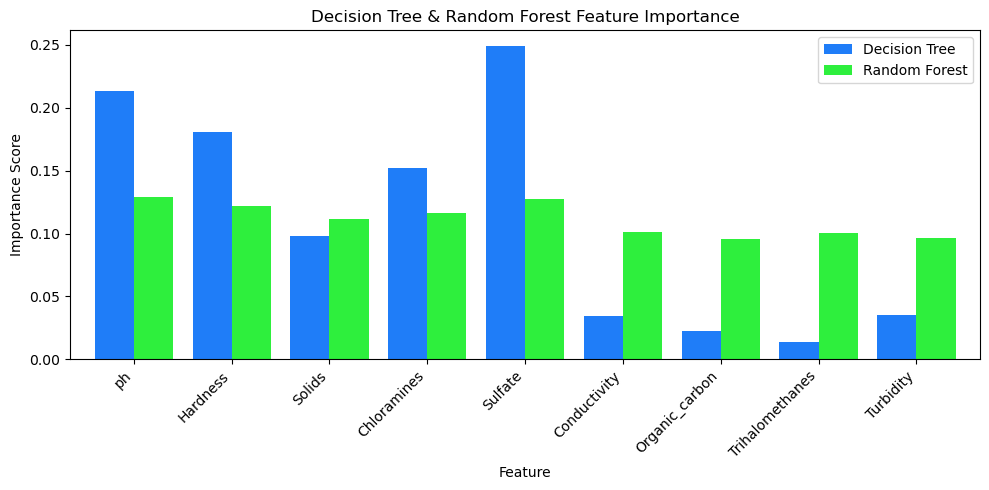

In [41]:
# Visualize coefficient estimates for OLS, Ridge, and Lasso
importance_df = pd.DataFrame({
    'Decision Tree': dt_opt.feature_importances_,
    'Random Forest': rf.feature_importances_
}, index=features)

ax = importance_df.plot.bar(figsize = (10,5), width=0.8, color=['#1f7df8', '#2EEF3D'])
ax.set_xticklabels(features, rotation = 45, ha = 'right')
ax.set_title('Decision Tree & Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()





> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The decision tree and random forest disagree which features are most important. While they both recognize sulfate as the most important, the random forest also identified almost all the features as similarly important. The decision tree shows a couple of high importance features, indicating the decision trees picking a couple of high importance predictors based on the early splits. Random forest breaks this by picking a random set of features at each split, reducing variance and making the results more reliable. Sulfate, ph, and Hardness are the most important features for both the decision tree and the random forest for predicting potability, which makes sense because these features can have the greatest effect on health if the drinking water is contaminated. 

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

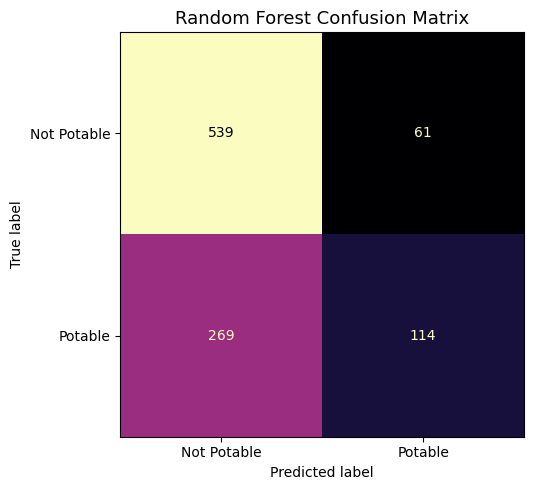

In [45]:
# Create confusion matrix
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Potable", "Potable"])


fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar = False, cmap = "magma")
ax.set_ylim(len(["Not Potable", "Potable"]) - 0.5, -0.5)
ax.set_title('Random Forest Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

- True negative = 539 (A not potable water sample classified as not potable )
- False negative = 269 (A Potable water sample classified as not potable)
- True positive = 114 (A potable water sample classified as potable)
- False positive = 61 (A non potable water sample classified as potable)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [46]:
# Create table to compare test accuracies
summary_df = pd.DataFrame({
    'Model': ['Unpruned decision tree', 'Tuned decision tree', 'Random forest'],
    'Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf]
})

print(summary_df.to_string(index=False))


                 Model  Accuracy
Unpruned decision tree  0.580875
   Tuned decision tree  0.645982
         Random forest  0.664293


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


Random forest achieved the highest test accuracy of .66. Between pruned and unpruned the accuracy on test data increased by .06. This shows that the unpruned tree is overfitting to the training data as the accuracy is lower than the pruned, meaning it is worse at classifying new data than the tuned decision tree. 

---

Run the cell below to receive credit for autograded questions. 

In [47]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError